# Lab 5 + 6 — Augmentacja danych dla CNN + Rekurencyjne Sieci Neuronowe

**Wybrane Zagadnienia / Zaawansowane Metody Sztucznej Inteligencji · II stopień**

---

## Co zrobimy na tym podwójnym labie

**Część 1 — Lab 5: Augmentacja danych dla CNN**
1. **Dlaczego augmentacja?** — overfitting i mały dataset
2. **Galeria technik** — geometria, kolor, maskowanie, Mixup/CutMix
3. **ImageDataGenerator** — "on-the-fly" augmentacja w TensorFlow
4. **CIFAR-10 baseline** — CNN bez augmentacji (overfittuje)
5. **CIFAR-10 z augmentacją** — porównanie
6. **Hyperparameter tuning** — Random Search + KFold dla zakresów augmentacji

**Część 2 — Lab 6: RNN, LSTM, GRU**
1. **Po co RNN?** — dane sekwencyjne vs siatkowe (CNN)
2. **Architektura RNN** — pętla rekurencyjna, stan ukryty, BPTT
3. **Typy struktur** — one-to-many, many-to-one, seq2seq
4. **Vanishing/exploding gradient** — problem i rozwiązania
5. **LSTM** — bramki forget/input/output
6. **GRU** — uproszczona alternatywa
7. **DEMO LSTM** — predykcja sinusoidy z szumem (zadanie z PDF)

**Część 3 — Zadania samodzielne**
- Lab 5: CIFAR-10 z optymalizacją parametrów augmentacji
- Lab 6: PM-10 prediction dla Krakowa (Złoty Róg)

---

## 0. Setup

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("\nTip: na CPU CIFAR uczy sie ~2-3 min, LSTM ~30s. Na GPU 10x szybciej.")

TensorFlow: 2.21.0
GPU: False

Tip: na CPU CIFAR uczy sie ~2-3 min, LSTM ~30s. Na GPU 10x szybciej.


---

# CZĘŚĆ 1 — Lab 5: Augmentacja danych dla CNN

## 1.1. Dlaczego augmentacja?

**Problem:** CNN potrzebuje **dużo** danych żeby się dobrze generalizować. Jeśli masz 1000 zdjęć kota i 1000 psa — model zapamiętuje **te konkretne** zdjęcia (overfitting), a nie *czym jest kot*.

**Rozwiązanie:** sztucznie zwiększamy dataset przez **transformacje** istniejących zdjęć. Kot obrócony o 10° to nadal kot. Kot z większą jasnością to nadal kot. Sieć uczy się **inwariantności**.

### Trzy główne korzyści

| Korzyść | Dlaczego |
|---------|----------|
| **Zapobieganie overfittingowi** | Sieć nie widzi nigdy dwa razy tego samego zdjęcia |
| **Symulowanie rzeczywistych wariacji** | W realnym świecie kot może być pod różnym kątem |
| **Zwiększanie datasetu "za darmo"** | Bez zbierania nowych danych |

### Dwie praktyki

- **On-the-fly** — augmentacja w czasie treningu, każda epoka = nowe wersje (popularne, oszczędza dysk)
- **Pre-processing** — generujemy zmienione zdjęcia z wyprzedzeniem i zapisujemy (rzadziej)

## 1.2. Galeria technik augmentacji

Pokażemy każdą technikę na jednym obrazku z MNIST/CIFAR, żeby było widać efekt.

c:\Users\wojci\miniconda3\envs\base_ai\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


x_cifar_train: (50000, 32, 32, 3)  (50k obrazow 32x32x3)
y_cifar_train: (50000, 1)

Obraz testowy: pies


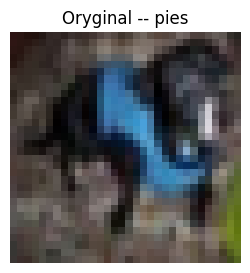

In [8]:
# Wczytaj CIFAR-10 (10 klas obrazow 32x32 RGB)
(x_cifar_train, y_cifar_train), (x_cifar_test, y_cifar_test) = keras.datasets.cifar10.load_data()

class_names = ['samolot', 'auto', 'ptak', 'kot', 'jelen',
               'pies', 'zaba', 'kon', 'statek', 'ciezarowka']

print(f"x_cifar_train: {x_cifar_train.shape}  (50k obrazow 32x32x3)")
print(f"y_cifar_train: {y_cifar_train.shape}")

# Wybierzmy jeden obrazek -- np. psa
idx = np.where(y_cifar_train.flatten() == 5)[0][0]  # pies
obraz = x_cifar_train[idx]
print(f"\nObraz testowy: {class_names[y_cifar_train[idx][0]]}")

plt.figure(figsize=(3, 3))
plt.imshow(obraz)
plt.title(f"Oryginal -- {class_names[y_cifar_train[idx][0]]}")
plt.axis('off')
plt.show()

### Grupa A: Transformacje geometryczne

**Obrót, odbicie, skalowanie, przesunięcie, ścinanie.** Zmieniają **pozycję pikseli** ale nie ich wartości.

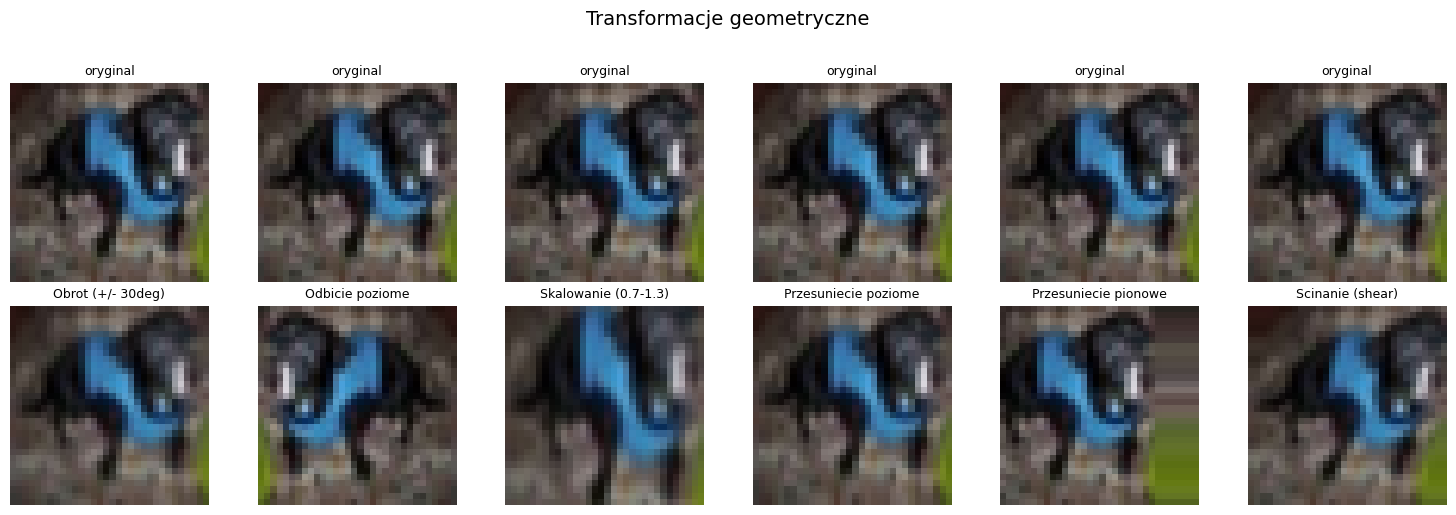

In [9]:
# Galeria transformacji geometrycznych
from tensorflow.keras.preprocessing.image import ImageDataGenerator

obraz_batch = np.expand_dims(obraz, 0)  # (1, 32, 32, 3) -- IDG wymaga batcha

transforms_geo = {
    "Obrot (+/- 30deg)":   ImageDataGenerator(rotation_range=30),
    "Odbicie poziome":     ImageDataGenerator(horizontal_flip=True),
    "Skalowanie (0.7-1.3)":ImageDataGenerator(zoom_range=0.3),
    "Przesuniecie poziome":ImageDataGenerator(width_shift_range=0.2),
    "Przesuniecie pionowe":ImageDataGenerator(height_shift_range=0.2),
    "Scinanie (shear)":    ImageDataGenerator(shear_range=20),
}

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for col, (name, gen) in enumerate(transforms_geo.items()):
    axes[0, col].imshow(obraz)
    axes[0, col].set_title("oryginal", fontsize=9)
    axes[0, col].axis('off')
    aug_iter = gen.flow(obraz_batch, batch_size=1, seed=col)
    aug = next(aug_iter)[0].astype('uint8')
    axes[1, col].imshow(aug)
    axes[1, col].set_title(name, fontsize=9)
    axes[1, col].axis('off')
plt.suptitle("Transformacje geometryczne", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Grupa B: Modyfikacje intensywności i kolorów

**Jasność, kontrast, nasycenie, szum.** Zmieniają **wartości pikseli** ale nie ich pozycje.

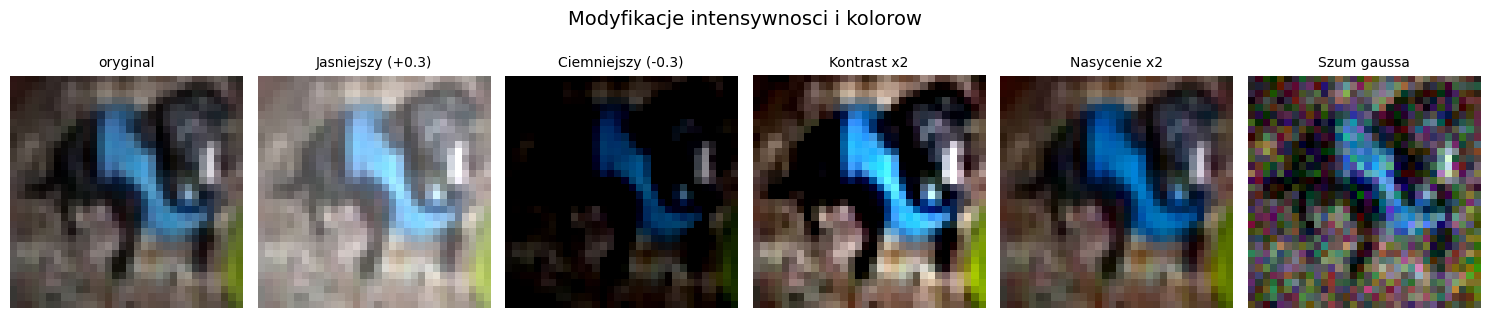

In [10]:
# Reczne implementacje (IDG nie ma wszystkich tych opcji)
from tensorflow.image import (adjust_brightness, adjust_contrast,
                              adjust_saturation)

obraz_f = obraz.astype('float32') / 255.0

transforms_color = {
    "Jasniejszy (+0.3)": adjust_brightness(obraz_f, 0.3).numpy(),
    "Ciemniejszy (-0.3)": adjust_brightness(obraz_f, -0.3).numpy(),
    "Kontrast x2":        adjust_contrast(obraz_f, 2.0).numpy(),
    "Nasycenie x2":       adjust_saturation(obraz_f, 2.0).numpy(),
    "Szum gaussa":        np.clip(obraz_f + np.random.normal(0, 0.1, obraz_f.shape), 0, 1),
}

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(obraz)
axes[0].set_title("oryginal", fontsize=10)
axes[0].axis('off')
for col, (name, aug) in enumerate(transforms_color.items(), 1):
    axes[col].imshow(np.clip(aug, 0, 1))
    axes[col].set_title(name, fontsize=10)
    axes[col].axis('off')
plt.suptitle("Modyfikacje intensywnosci i kolorow", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### Grupa C: Cięcie i maskowanie (Random Erasing, Mixup, CutMix)

**Zaawansowane techniki 2020+.** Wymuszają na sieci, żeby nie patrzyła tylko na jeden fragment obrazu.

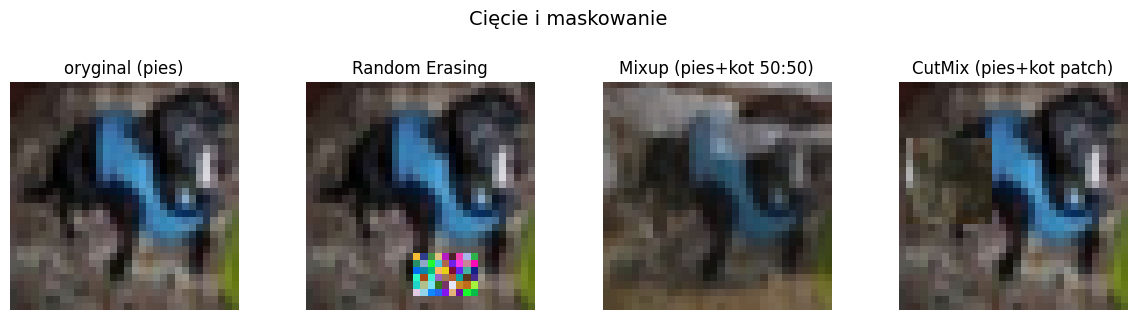

In [11]:
def random_erasing(img, max_size=0.3):
    """Losowe wymazanie kawalka obrazu."""
    img = img.copy()
    h, w = img.shape[:2]
    sh = int(h * np.random.uniform(0.1, max_size))
    sw = int(w * np.random.uniform(0.1, max_size))
    y = np.random.randint(0, h - sh)
    x = np.random.randint(0, w - sw)
    img[y:y+sh, x:x+sw] = np.random.randint(0, 255, (sh, sw, 3))
    return img

def mixup(img1, img2, alpha=0.5):
    """Liniowa interpolacja dwoch obrazow."""
    return (alpha * img1 + (1 - alpha) * img2).astype('uint8')

def cutmix(img1, img2, frac=0.4):
    """Wycinamy kawalek img2 i wklejamy do img1."""
    img = img1.copy()
    h, w = img.shape[:2]
    sh = int(h * frac); sw = int(w * frac)
    y = np.random.randint(0, h - sh); x = np.random.randint(0, w - sw)
    img[y:y+sh, x:x+sw] = img2[y:y+sh, x:x+sw]
    return img

# Drugi obraz -- kot
idx2 = np.where(y_cifar_train.flatten() == 3)[0][0]
obraz2 = x_cifar_train[idx2]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(obraz); axes[0].set_title("oryginal (pies)"); axes[0].axis('off')
axes[1].imshow(random_erasing(obraz)); axes[1].set_title("Random Erasing"); axes[1].axis('off')
axes[2].imshow(mixup(obraz, obraz2)); axes[2].set_title("Mixup (pies+kot 50:50)"); axes[2].axis('off')
axes[3].imshow(cutmix(obraz, obraz2)); axes[3].set_title("CutMix (pies+kot patch)"); axes[3].axis('off')
plt.suptitle("Cięcie i maskowanie", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

---

## 1.3. ImageDataGenerator — augmentacja w treningu

`ImageDataGenerator` to klasa Keras, która **w czasie rzeczywistym** generuje zmienione wersje obrazów dla każdej epoki.

**Kluczowy zysk:** sieć w 100 epok widzi **100 różnych** wersji każdego obrazu. Bez augmentacji widzi ten sam 100 razy.

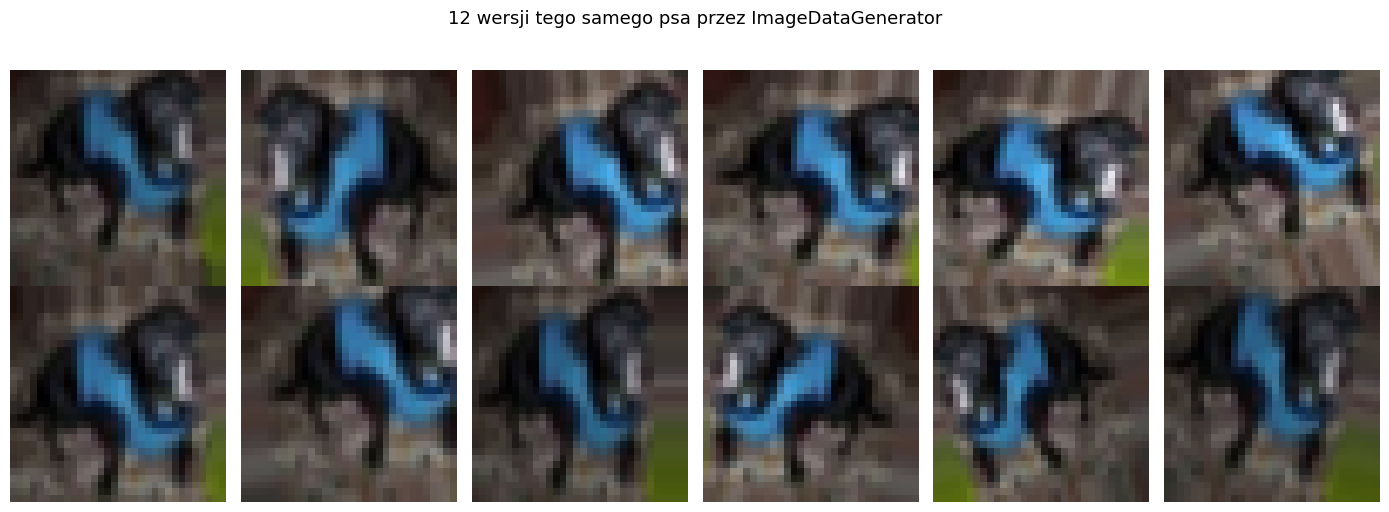

Kazda komorka to ten sam piksel, ale po roznych transformacjach.
To dziala na BIEZACO podczas .fit() -- nie zapisujemy zmodyfikowanych obrazow.


In [12]:
# Demonstracja: 12 wersji tego samego psa z augmentacja "all-in"
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.7, 1.3),
)

aug_iter = datagen.flow(np.expand_dims(obraz, 0), batch_size=1)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax in axes.flat:
    aug = next(aug_iter)[0].astype('uint8')
    ax.imshow(aug)
    ax.axis('off')
plt.suptitle("12 wersji tego samego psa przez ImageDataGenerator", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Kazda komorka to ten sam piksel, ale po roznych transformacjach.")
print("To dziala na BIEZACO podczas .fit() -- nie zapisujemy zmodyfikowanych obrazow.")

---

## 1.4. Baseline CNN — CIFAR-10 BEZ augmentacji

Najpierw trenujemy **bez** augmentacji. Zobaczymy wyraźny overfitting.

**Setup zadania (z PDF):**
- Ograniczamy CIFAR-10 do **4 klas i 2000 zdjęć** (szybsza optymalizacja)
- Normalizacja (mean/std)
- One-hot encoding etykiet

In [13]:
# Ograniczamy do 4 klas i 2000 zdjec
KLASY = [3, 5, 6, 7]  # kot, pies, zaba, kon
N_CLASSES = len(KLASY)
N_TRAIN = 2000

# Filtruj train
mask_train = np.isin(y_cifar_train.flatten(), KLASY)
x_tr = x_cifar_train[mask_train][:N_TRAIN]
y_tr = y_cifar_train[mask_train][:N_TRAIN]

# Filtruj test
mask_test = np.isin(y_cifar_test.flatten(), KLASY)
x_te = x_cifar_test[mask_test]
y_te = y_cifar_test[mask_test]

# Przemapuj etykiety na 0..3
label_map = {orig: new for new, orig in enumerate(KLASY)}
y_tr = np.vectorize(label_map.get)(y_tr.flatten())
y_te = np.vectorize(label_map.get)(y_te.flatten())

# Normalizacja (mean/std) -- standard ML practice
x_tr_f = x_tr.astype('float32')
x_te_f = x_te.astype('float32')
mean = x_tr_f.mean(axis=(0, 1, 2))
std = x_tr_f.std(axis=(0, 1, 2))
x_tr_norm = (x_tr_f - mean) / std
x_te_norm = (x_te_f - mean) / std

# One-hot
y_tr_oh = keras.utils.to_categorical(y_tr, N_CLASSES)
y_te_oh = keras.utils.to_categorical(y_te, N_CLASSES)

print(f"Klasy: {[class_names[k] for k in KLASY]}")
print(f"x_tr: {x_tr_norm.shape}, y_tr_oh: {y_tr_oh.shape}")
print(f"x_te: {x_te_norm.shape}, y_te_oh: {y_te_oh.shape}")

Klasy: ['kot', 'pies', 'zaba', 'kon']
x_tr: (2000, 32, 32, 3), y_tr_oh: (2000, 4)
x_te: (4000, 32, 32, 3), y_te_oh: (4000, 4)


In [14]:
def cnn_model(num_filters=32, dropout_conv=0.0, dropout_dense=0.5):
    """CNN architecture z PDF -- 3 bloki conv + dense + softmax.
    Mniejsza wersja niz w PDF zeby trening byl szybki.
    """
    model = keras.Sequential([
        layers.Conv2D(num_filters, 3, activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        layers.Conv2D(2*num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(2*num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_dense),
        layers.Dense(N_CLASSES, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Baseline -- bez augmentacji
print("=== Baseline CNN (BEZ augmentacji) ===")
tf.random.set_seed(42)
model_baseline = cnn_model()
hist_baseline = model_baseline.fit(
    x_tr_norm, y_tr_oh,
    epochs=15, batch_size=64,
    validation_split=0.2,
    verbose=2
)
test_loss_b, test_acc_b = model_baseline.evaluate(x_te_norm, y_te_oh, verbose=0)
print(f"\nTest accuracy BEZ augmentacji: {test_acc_b:.4f}")

=== Baseline CNN (BEZ augmentacji) ===
Epoch 1/15


c:\Users\wojci\miniconda3\envs\base_ai\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 - 6s - 245ms/step - accuracy: 0.4306 - loss: 1.7413 - val_accuracy: 0.3675 - val_loss: 1.2861
Epoch 2/15
25/25 - 1s - 49ms/step - accuracy: 0.6144 - loss: 1.0500 - val_accuracy: 0.3775 - val_loss: 1.4074
Epoch 3/15
25/25 - 1s - 50ms/step - accuracy: 0.6938 - loss: 0.8196 - val_accuracy: 0.3975 - val_loss: 1.4133
Epoch 4/15
25/25 - 1s - 48ms/step - accuracy: 0.7769 - loss: 0.5960 - val_accuracy: 0.3600 - val_loss: 1.4361
Epoch 5/15
25/25 - 1s - 50ms/step - accuracy: 0.8594 - loss: 0.4039 - val_accuracy: 0.3175 - val_loss: 1.3997
Epoch 6/15
25/25 - 1s - 49ms/step - accuracy: 0.9031 - loss: 0.2814 - val_accuracy: 0.3375 - val_loss: 1.4229
Epoch 7/15
25/25 - 1s - 50ms/step - accuracy: 0.9287 - loss: 0.2195 - val_accuracy: 0.3425 - val_loss: 1.5130
Epoch 8/15
25/25 - 1s - 49ms/step - accuracy: 0.9556 - loss: 0.1698 - val_accuracy: 0.3750 - val_loss: 1.5059
Epoch 9/15
25/25 - 1s - 48ms/step - accuracy: 0.9556 - loss: 0.1456 - val_accuracy: 0.4225 - val_loss: 1.5008
Epoch 10/15
25/25 - 

## 1.5. CNN Z augmentacją

In [15]:
# Trening Z augmentacja przez ImageDataGenerator
print("=== CNN Z augmentacja ===")

datagen_train = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

# Podzial na train/val przed generatorem
split = int(0.8 * len(x_tr_norm))
x_t, x_v = x_tr_norm[:split], x_tr_norm[split:]
y_t, y_v = y_tr_oh[:split], y_tr_oh[split:]

tf.random.set_seed(42)
model_aug = cnn_model()
hist_aug = model_aug.fit(
    datagen_train.flow(x_t, y_t, batch_size=64),
    epochs=15,
    validation_data=(x_v, y_v),
    verbose=2
)
test_loss_a, test_acc_a = model_aug.evaluate(x_te_norm, y_te_oh, verbose=0)
print(f"\nTest accuracy Z augmentacja: {test_acc_a:.4f}")

=== CNN Z augmentacja ===
Epoch 1/15
25/25 - 6s - 236ms/step - accuracy: 0.3988 - loss: 1.8580 - val_accuracy: 0.3675 - val_loss: 1.3408
Epoch 2/15
25/25 - 2s - 64ms/step - accuracy: 0.4944 - loss: 1.3914 - val_accuracy: 0.3225 - val_loss: 1.3550
Epoch 3/15
25/25 - 2s - 63ms/step - accuracy: 0.5263 - loss: 1.2502 - val_accuracy: 0.4325 - val_loss: 1.2352
Epoch 4/15
25/25 - 2s - 63ms/step - accuracy: 0.5387 - loss: 1.1781 - val_accuracy: 0.3900 - val_loss: 1.3579
Epoch 5/15
25/25 - 2s - 64ms/step - accuracy: 0.5863 - loss: 1.0710 - val_accuracy: 0.3525 - val_loss: 1.3931
Epoch 6/15
25/25 - 2s - 65ms/step - accuracy: 0.5869 - loss: 1.0086 - val_accuracy: 0.3400 - val_loss: 1.3908
Epoch 7/15
25/25 - 2s - 64ms/step - accuracy: 0.6325 - loss: 0.9247 - val_accuracy: 0.4500 - val_loss: 1.3448
Epoch 8/15
25/25 - 2s - 64ms/step - accuracy: 0.6413 - loss: 0.8800 - val_accuracy: 0.4375 - val_loss: 1.3527
Epoch 9/15
25/25 - 2s - 63ms/step - accuracy: 0.6600 - loss: 0.8414 - val_accuracy: 0.4575 - 

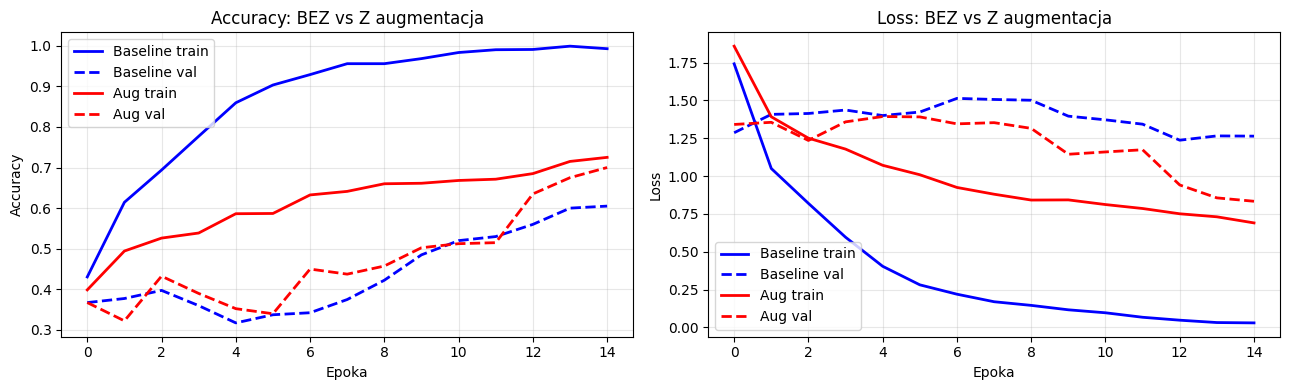


=== WYNIKI ===
Baseline (bez aug): test acc = 0.5903
Z augmentacja:      test acc = 0.6580
Roznica:            +6.77%

Obserwacja: baseline OVERFITTUJE -- train acc rosnie do 100%, val acc stoi.
Z augmentacja: train acc nizsze, ale val/test acc wyzsze -> lepsza generalizacja.


In [16]:
# Porownanie krzywych uczenia
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_baseline.history['accuracy'], 'b-', label='Baseline train', linewidth=2)
axes[0].plot(hist_baseline.history['val_accuracy'], 'b--', label='Baseline val', linewidth=2)
axes[0].plot(hist_aug.history['accuracy'], 'r-', label='Aug train', linewidth=2)
axes[0].plot(hist_aug.history['val_accuracy'], 'r--', label='Aug val', linewidth=2)
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: BEZ vs Z augmentacja')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_baseline.history['loss'], 'b-', label='Baseline train', linewidth=2)
axes[1].plot(hist_baseline.history['val_loss'], 'b--', label='Baseline val', linewidth=2)
axes[1].plot(hist_aug.history['loss'], 'r-', label='Aug train', linewidth=2)
axes[1].plot(hist_aug.history['val_loss'], 'r--', label='Aug val', linewidth=2)
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss: BEZ vs Z augmentacja')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== WYNIKI ===")
print(f"Baseline (bez aug): test acc = {test_acc_b:.4f}")
print(f"Z augmentacja:      test acc = {test_acc_a:.4f}")
print(f"Roznica:            {(test_acc_a - test_acc_b)*100:+.2f}%")
print("\nObserwacja: baseline OVERFITTUJE -- train acc rosnie do 100%, val acc stoi.")
print("Z augmentacja: train acc nizsze, ale val/test acc wyzsze -> lepsza generalizacja.")

---

## 1.6. Hyperparameter tuning — Random Search

Z PDF: *"Potraktuj zakresy transformacji geometrycznych jako hiperparametry modelu i przeprowadź ich dobór (np. przy użyciu podejścia Random Search). Jako kryterium optymalizacji wykorzystaj dokładność uzyskaną w wyniku kroswalidacji k-fold."*

**Mini-demo:** sprawdzimy 4 losowe konfiguracje augmentacji i wybierzemy najlepszą po prostym holdout (zamiast pełnego KFold, żeby zmieścić się czasowo).

In [17]:
import time

# Przestrzen hiperparametrow
search_space = {
    'rotation_range':     [0, 10, 20, 30],
    'width_shift_range':  [0.0, 0.1, 0.2],
    'zoom_range':         [0.0, 0.1, 0.2],
}

def sample_config():
    return {k: np.random.choice(v) for k, v in search_space.items()}

N_TRIALS = 4  # zwieksz do 10+ dla rzetelnej optymalizacji

results = []
for trial in range(N_TRIALS):
    config = sample_config()
    t0 = time.time()
    print(f"\nTrial {trial+1}/{N_TRIALS}: {dict(config)}")
    
    datagen = ImageDataGenerator(
        rotation_range=int(config['rotation_range']),
        width_shift_range=float(config['width_shift_range']),
        zoom_range=float(config['zoom_range']),
        horizontal_flip=True,
    )
    
    tf.random.set_seed(42)
    model = cnn_model()
    hist = model.fit(
        datagen.flow(x_t, y_t, batch_size=64),
        epochs=8, validation_data=(x_v, y_v), verbose=0
    )
    val_acc = hist.history['val_accuracy'][-1]
    elapsed = time.time() - t0
    results.append({'config': dict(config), 'val_acc': val_acc, 'time': elapsed})
    print(f"  val_acc = {val_acc:.4f}  ({elapsed:.1f}s)")

# Najlepszy
best = max(results, key=lambda r: r['val_acc'])
print(f"\n=== Najlepsza konfiguracja ===")
print(f"Config: {best['config']}")
print(f"Val accuracy: {best['val_acc']:.4f}")


Trial 1/4: {'rotation_range': np.int64(0), 'width_shift_range': np.float64(0.0), 'zoom_range': np.float64(0.1)}
  val_acc = 0.4125  (16.3s)

Trial 2/4: {'rotation_range': np.int64(30), 'width_shift_range': np.float64(0.0), 'zoom_range': np.float64(0.1)}
  val_acc = 0.3350  (16.2s)

Trial 3/4: {'rotation_range': np.int64(30), 'width_shift_range': np.float64(0.0), 'zoom_range': np.float64(0.2)}
  val_acc = 0.3275  (16.3s)

Trial 4/4: {'rotation_range': np.int64(30), 'width_shift_range': np.float64(0.1), 'zoom_range': np.float64(0.2)}
  val_acc = 0.5375  (16.8s)

=== Najlepsza konfiguracja ===
Config: {'rotation_range': np.int64(30), 'width_shift_range': np.float64(0.1), 'zoom_range': np.float64(0.2)}
Val accuracy: 0.5375


---

# CZĘŚĆ 2 — Lab 6: Rekurencyjne Sieci Neuronowe (RNN)

## 2.1. Most: dlaczego CNN nie wystarczy?

**CNN (Lab 4-5)** ekstrahuje cechy z **siatek** o stałym rozmiarze (obrazy 32x32, 224x224, ...). 

Co jeśli dane są **sekwencjami** o zmiennej długości?
- **Tekst:** "Lubię koty" (3 słowa) vs "Lubię koty i psy" (5 słów)
- **Szeregi czasowe:** kursy walut, temperatury, pomiary IoT
- **Audio:** sygnał o długości 1s lub 10s
- **DNA:** sekwencje nukleotydów

**CNN ignoruje kolejność.** Dla sekwencji potrzebujemy sieci, która **pamięta** poprzednie elementy.

## 2.2. Architektura RNN

**Kluczowa idea:** **pętla rekurencyjna**. Sieć ma **stan ukryty** $a_t$ który aktualizuje się przy każdym kroku czasowym.

$$a_t = g_1(W_{aa} a_{t-1} + W_{ax} x_t + b_a)$$
$$y_t = g_2(W_{ya} a_t + b_y)$$

**Czytaj to jako:** "nowy stan = funkcja(stary stan, nowe wejście)".

### Kluczowe cechy RNN

| Cecha | Co znaczy |
|-------|-----------|
| **Pamięć wewnętrzna** | Stan ukryty zapamiętuje kontekst |
| **Przetwarzanie sekwencyjne** | Kolejność elementów ma znaczenie |
| **Współdzielone wagi** | Te same $W_{aa}, W_{ax}, W_{ya}$ dla każdego kroku |
| **Dynamiczne** | Działa na sekwencjach o dowolnej długości |

**Trening: BPTT** — Backpropagation Through Time. Rozwijasz sieć w czasie (jak T kopii MLP) i propagujesz gradient wstecz przez wszystkie kroki.

## 2.3. Typy struktur RNN

| Typ | Schemat | Przykład zastosowania |
|-----|---------|----------------------|
| **One-to-one** ($T_x=T_y=1$) | x → y | Klasyczna klasyfikacja (= MLP) |
| **One-to-many** ($T_x=1, T_y>1$) | x → y₁, y₂, ... | Generowanie muzyki, captioning obrazów |
| **Many-to-one** ($T_x>1, T_y=1$) | x₁, x₂, ... → y | Analiza sentymentu, klasyfikacja sekwencji |
| **Many-to-many (equal)** ($T_x=T_y$) | x_t → y_t | Tagowanie sekwencji (NER) |
| **Many-to-many (seq2seq)** ($T_x ≠ T_y$) | x_1..T_x → y_1..T_y | Tłumaczenie maszynowe |

## 2.4. Problem: Vanishing i Exploding Gradient

W BPTT mnożymy gradienty przez wiele kroków czasowych. Konsekwencje:

### Vanishing gradient
- **Przyczyna:** pochodne sigmoidy/tanh są < 1. Mnożenie ich wielokrotnie → wartość zbliża się do 0.
- **Skutek:** sieć **zapomina** informacje z początku sekwencji.
- **Matematyka:** jeśli $|\partial a_t / \partial a_{t-1}| < 1$, to $\prod$ → 0.

### Exploding gradient
- **Przyczyna:** wagi duże, pochodne >> 1. Mnożenie → wybuch.
- **Skutek:** wagi NaN, model nie zbiega.

### Rozwiązania

1. **Gradient Clipping** — ucinamy gradient powyżej progu (`clipnorm=1.0` w Keras)
2. **Bramki — LSTM / GRU** — kontrolowany przepływ informacji
3. **Regularyzacja/normalizacja** — L2, BatchNorm, LayerNorm

## 2.5. LSTM — Long Short-Term Memory

**LSTM** rozwiązuje vanishing gradient przez **komórkę pamięci** $C_t$ i **bramki** (gates).

### Trzy bramki

1. **Forget gate** $F_t$ — *co zapomnieć z pamięci?*
2. **Input gate** $I_t$ — *co nowego dodać do pamięci?*
3. **Output gate** $O_t$ — *co wypuścić jako wyjście?*

### Równania (6 kroków)

$$F_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{forget gate}$$
$$I_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{input gate}$$
$$\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \quad \text{kandydat na pamięć}$$
$$C_t = F_t \odot C_{t-1} + I_t \odot \tilde{C}_t \quad \text{aktualizacja pamięci}$$
$$O_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{output gate}$$
$$h_t = O_t \odot \tanh(C_t) \quad \text{nowy stan ukryty}$$

(⊙ = iloczyn Hadamarda = mnożenie element po elemencie)

**Intuicja:** komórka pamięci $C_t$ to "taśma transportowa". Forget gate decyduje co usunąć, input gate co dodać. Gradient przepływa przez tę taśmę **bez znaczących mnożeń**, więc nie zanika.

## 2.6. GRU — Gated Recurrent Unit

**GRU** = uproszczona LSTM. Tylko **2 bramki** (reset, update) i brak osobnej komórki pamięci.

**Plusy:** mniej parametrów, szybszy trening.  
**Minusy:** czasem gorszy w bardzo długich sekwencjach.

**W praktyce:** zacznij od LSTM, spróbuj GRU jeśli wolne.

---

## 2.7. DEMO LSTM — predykcja sinusoidy z szumem

**Zadanie z PDF (Lab 6, Zadanie 9):** Zbuduj LSTM przewidujący sekwencję sinusoidalną z dodanym szumem.

**Plan:**
1. Generujemy szereg czasowy: `sin(arange) + szum`
2. Tworzymy sekwencje wejściowe (look_back=20) i wyjścia (1 punkt)
3. Dzielimy na train/test
4. Budujemy LSTM
5. Trenujemy i wizualizujemy

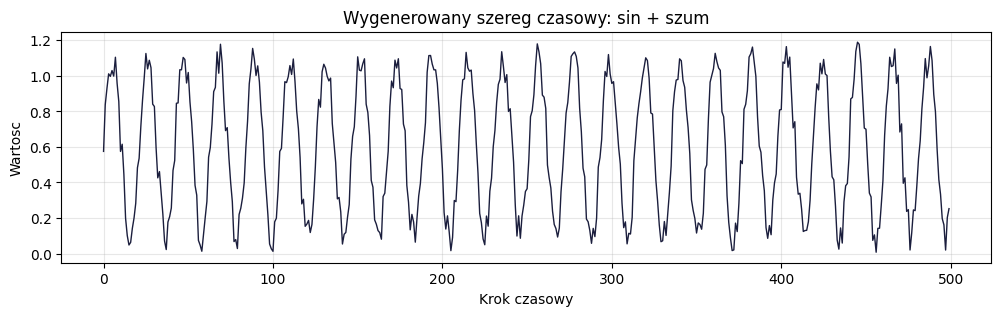

Dlugosc szeregu: 500
Zakres: [0.007, 1.189]


In [18]:
# Krok 1: Generujemy szereg czasowy
np.random.seed(42)
N = 500
t = np.arange(N)
signal = np.sin(t * 0.3) * 0.5 + 0.5 + np.random.rand(N) * 0.2

plt.figure(figsize=(12, 3))
plt.plot(t, signal, color='#1B1E3D', linewidth=1)
plt.title("Wygenerowany szereg czasowy: sin + szum")
plt.xlabel("Krok czasowy")
plt.ylabel("Wartosc")
plt.grid(alpha=0.3)
plt.show()

print(f"Dlugosc szeregu: {N}")
print(f"Zakres: [{signal.min():.3f}, {signal.max():.3f}]")

In [19]:
# Krok 2: Sekwencje (X) i targety (y) z look_back
look_back = 20

X, y = [], []
for i in range(look_back, len(signal)):
    X.append(signal[i - look_back:i])
    y.append(signal[i])

X = np.array(X).reshape(-1, look_back, 1)  # (samples, timesteps, features)
y = np.array(y)

print(f"X shape: {X.shape}  (n_sequences, look_back, n_features)")
print(f"y shape: {y.shape}")

# Podzial train/test (70/30 -- jak w PDF rysunku)
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"\nTrain: {X_train.shape[0]} sekwencji")
print(f"Test:  {X_test.shape[0]} sekwencji")

X shape: (480, 20, 1)  (n_sequences, look_back, n_features)
y shape: (480,)

Train: 336 sekwencji
Test:  144 sekwencji


In [20]:
# Krok 3: Model LSTM
from tensorflow.keras.layers import LSTM, Dropout, Dense

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    LSTM(8, input_shape=(look_back, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()

c:\Users\wojci\miniconda3\envs\base_ai\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
21/21 - 2s - 75ms/step - loss: 0.3156 - val_loss: 0.2325
Epoch 2/20
21/21 - 0s - 8ms/step - loss: 0.1802 - val_loss: 0.1633
Epoch 3/20
21/21 - 0s - 8ms/step - loss: 0.1492 - val_loss: 0.1507
Epoch 4/20
21/21 - 0s - 9ms/step - loss: 0.1376 - val_loss: 0.1414
Epoch 5/20
21/21 - 0s - 7ms/step - loss: 0.1296 - val_loss: 0.1337
Epoch 6/20
21/21 - 0s - 8ms/step - loss: 0.1228 - val_loss: 0.1269
Epoch 7/20
21/21 - 0s - 9ms/step - loss: 0.1168 - val_loss: 0.1210
Epoch 8/20
21/21 - 0s - 7ms/step - loss: 0.1114 - val_loss: 0.1157
Epoch 9/20
21/21 - 0s - 9ms/step - loss: 0.1066 - val_loss: 0.1108
Epoch 10/20
21/21 - 0s - 9ms/step - loss: 0.1021 - val_loss: 0.1062
Epoch 11/20
21/21 - 0s - 7ms/step - loss: 0.0979 - val_loss: 0.1020
Epoch 12/20
21/21 - 0s - 8ms/step - loss: 0.0939 - val_loss: 0.0979
Epoch 13/20
21/21 - 0s - 7ms/step - loss: 0.0901 - val_loss: 0.0940
Epoch 14/20
21/21 - 0s - 8ms/step - loss: 0.0864 - val_loss: 0.0901
Epoch 15/20
21/21 - 0s - 7ms/step - loss: 0.0828 - val_l

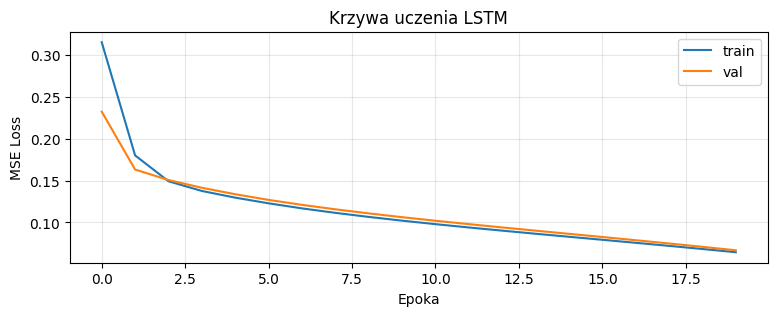

In [21]:
# Krok 4: Trening
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=20, batch_size=16,
    validation_data=(X_test, y_test),
    verbose=2
)

# Wykres loss
plt.figure(figsize=(9, 3))
plt.plot(history_lstm.history['loss'], label='train')
plt.plot(history_lstm.history['val_loss'], label='val')
plt.xlabel('Epoka')
plt.ylabel('MSE Loss')
plt.title('Krzywa uczenia LSTM')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

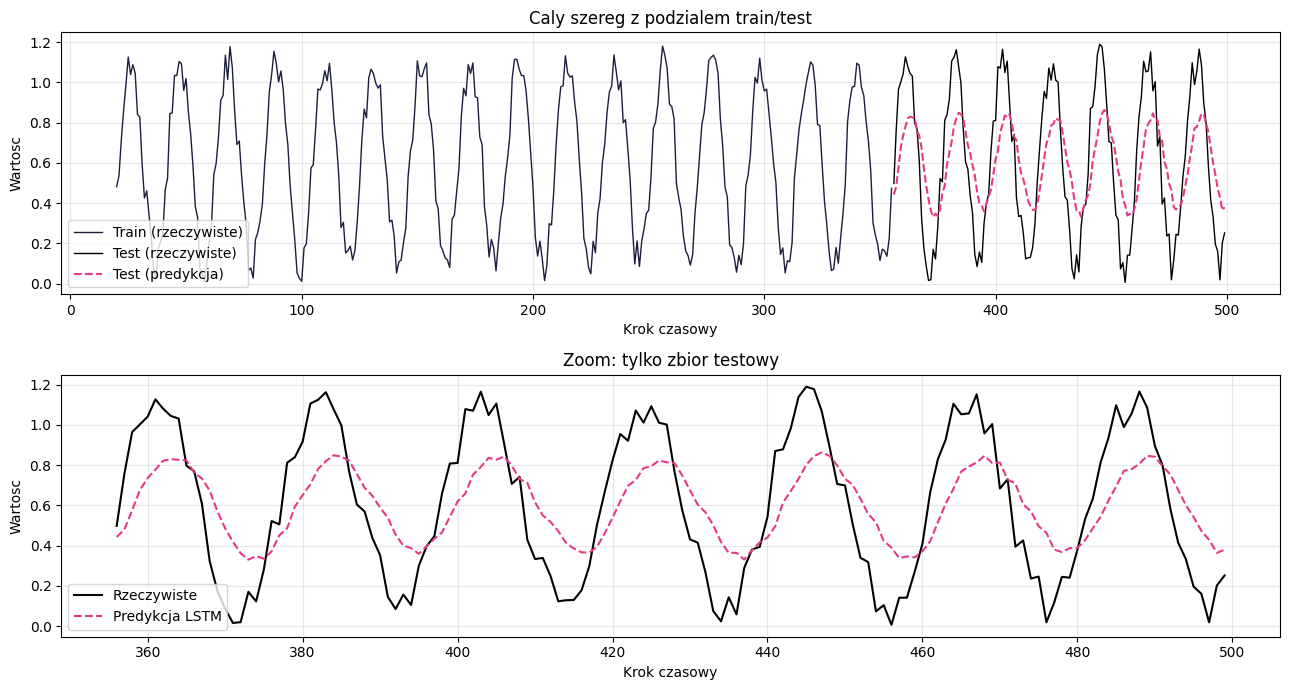


Test MSE: 0.066615
LSTM nauczyl sie rytmu sinusoidy mimo szumu.


In [22]:
# Krok 5: Predykcje
pred_test = model_lstm.predict(X_test, verbose=0).flatten()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Caly szereg z podzialem train/test
x_train_idx = np.arange(look_back, look_back + len(y_train))
x_test_idx = np.arange(look_back + len(y_train), look_back + len(y_train) + len(y_test))

axes[0].plot(x_train_idx, y_train, color='#1B1E3D', label='Train (rzeczywiste)', linewidth=1)
axes[0].plot(x_test_idx, y_test, color='black', label='Test (rzeczywiste)', linewidth=1)
axes[0].plot(x_test_idx, pred_test, color='#E63888', linestyle='--', label='Test (predykcja)', linewidth=1.5)
axes[0].set_title('Caly szereg z podzialem train/test')
axes[0].set_xlabel('Krok czasowy')
axes[0].set_ylabel('Wartosc')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Zoom na test
axes[1].plot(x_test_idx, y_test, color='black', label='Rzeczywiste', linewidth=1.5)
axes[1].plot(x_test_idx, pred_test, color='#E63888', linestyle='--', label='Predykcja LSTM', linewidth=1.5)
axes[1].set_title('Zoom: tylko zbior testowy')
axes[1].set_xlabel('Krok czasowy')
axes[1].set_ylabel('Wartosc')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

mse_test = ((y_test - pred_test) ** 2).mean()
print(f"\nTest MSE: {mse_test:.6f}")
print("LSTM nauczyl sie rytmu sinusoidy mimo szumu.")

---

# CZĘŚĆ 3 — Zadania do samodzielnego wykonania

## Zadanie A (Lab 5) — CIFAR-10 z optymalizacją augmentacji

Rozszerz powyższy mini-Random Search do **pełnego pipeline'u**:

1. Użyj **wszystkich 10 klas CIFAR-10** (lub minimum 5)
2. Dodaj do search_space: `height_shift_range`, `brightness_range`
3. **K-Fold cross-validation** (k=3 lub k=5) jako kryterium oceny
4. Min **10 prób** Random Search
5. Końcowy trening z najlepszą konfiguracją na pełnym datasecie
6. Ewaluacja na zbiorze testowym

**Bonus:** użyj `optuna` lub `hyperopt` zamiast Random Search.

In [23]:
# Zadanie A: KFold + Random Search dla CIFAR-10
from sklearn.model_selection import KFold
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

# Przygotowanie pelnego CIFAR-10 (10 klas)
X_train_full = x_cifar_train.astype('float32')
X_test_full = x_cifar_test.astype('float32')
y_train_full = y_cifar_train.flatten()
y_test_full = y_cifar_test.flatten()

mean_full = X_train_full.mean(axis=(0, 1, 2))
std_full = X_train_full.std(axis=(0, 1, 2))
X_train_full = (X_train_full - mean_full) / std_full
X_test_full = (X_test_full - mean_full) / std_full

y_train_full_oh = keras.utils.to_categorical(y_train_full, 10)
y_test_full_oh = keras.utils.to_categorical(y_test_full, 10)

def cnn_model_cifar10(num_filters=32, dropout_conv=0.15, dropout_dense=0.5):
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        layers.Conv2D(2 * num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(2 * num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_dense),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

search_space = {
    'rotation_range': [0, 10, 15, 20],
    'width_shift_range': [0.0, 0.08, 0.12],
    'height_shift_range': [0.0, 0.08, 0.12],
    'zoom_range': [0.0, 0.1, 0.2],
    'brightness_range': [None, (0.85, 1.15), (0.75, 1.25)]
}

def sample_config():
    return {key: values[np.random.randint(len(values))] for key, values in search_space.items()}

def build_datagen(config):
    datagen_kwargs = {
        'rotation_range': int(config['rotation_range']),
        'width_shift_range': float(config['width_shift_range']),
        'height_shift_range': float(config['height_shift_range']),
        'zoom_range': float(config['zoom_range']),
        'horizontal_flip': True,
    }
    if config['brightness_range'] is not None:
        datagen_kwargs['brightness_range'] = config['brightness_range']
    return ImageDataGenerator(**datagen_kwargs)

kf = KFold(n_splits=3, shuffle=True, random_state=42)
N_TRIALS = 10
SEARCH_EPOCHS = 2
BATCH_SIZE = 64
EARLY_STOPPING = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', restore_best_weights=True)

results = []
for trial in range(N_TRIALS):
    config = sample_config()
    fold_scores = []
    print(f'\nTrial {trial + 1}/{N_TRIALS}: {config}')

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_full), start=1):
        K.clear_session()
        tf.random.set_seed(42)

        x_fold_train = X_train_full[train_idx]
        y_fold_train = y_train_full_oh[train_idx]
        x_fold_val = X_train_full[val_idx]
        y_fold_val = y_train_full_oh[val_idx]

        datagen = build_datagen(config)
        model = cnn_model_cifar10()
        history = model.fit(
            datagen.flow(x_fold_train, y_fold_train, batch_size=BATCH_SIZE, seed=42),
            epochs=SEARCH_EPOCHS,
            validation_data=(x_fold_val, y_fold_val),
            callbacks=[EARLY_STOPPING],
            verbose=0
        )
        fold_scores.append(history.history['val_accuracy'][-1])

    mean_score = float(np.mean(fold_scores))
    results.append({'trial': trial + 1, 'config': config, 'mean_val_accuracy': mean_score})
    print(f'  mean val accuracy = {mean_score:.4f}')

results_df = pd.DataFrame(results).sort_values('mean_val_accuracy', ascending=False).reset_index(drop=True)
best_config_a = results_df.loc[0, 'config']
print('\n=== Random Search summary ===')
display(results_df)
print(f"\nBest configuration: {best_config_a}")


Trial 1/10: {'rotation_range': 10, 'width_shift_range': 0.12, 'height_shift_range': 0.0, 'zoom_range': 0.0, 'brightness_range': None}
  mean val accuracy = 0.6150

Trial 2/10: {'rotation_range': 20, 'width_shift_range': 0.12, 'height_shift_range': 0.08, 'zoom_range': 0.1, 'brightness_range': (0.75, 1.25)}
  mean val accuracy = 0.6100

Trial 3/10: {'rotation_range': 20, 'width_shift_range': 0.0, 'height_shift_range': 0.08, 'zoom_range': 0.2, 'brightness_range': None}
  mean val accuracy = 0.5866

Trial 4/10: {'rotation_range': 15, 'width_shift_range': 0.0, 'height_shift_range': 0.08, 'zoom_range': 0.0, 'brightness_range': (0.85, 1.15)}
  mean val accuracy = 0.6227

Trial 5/10: {'rotation_range': 20, 'width_shift_range': 0.08, 'height_shift_range': 0.0, 'zoom_range': 0.2, 'brightness_range': (0.75, 1.25)}
  mean val accuracy = 0.6054

Trial 6/10: {'rotation_range': 0, 'width_shift_range': 0.12, 'height_shift_range': 0.12, 'zoom_range': 0.1, 'brightness_range': (0.85, 1.15)}
  mean val a

,trial,config,mean_val_accuracy
0,4,"{'rotation_range': 15, 'width_shift_range': 0....",0.62268
1,1,"{'rotation_range': 10, 'width_shift_range': 0....",0.61498
2,9,"{'rotation_range': 0, 'width_shift_range': 0.1...",0.61440
3,6,"{'rotation_range': 0, 'width_shift_range': 0.1...",0.61074
4,2,"{'rotation_range': 20, 'width_shift_range': 0....",0.61000
5,5,"{'rotation_range': 20, 'width_shift_range': 0....",0.60540
6,8,"{'rotation_range': 0, 'width_shift_range': 0.1...",0.59574
7,7,"{'rotation_range': 0, 'width_shift_range': 0.1...",0.58800
8,3,"{'rotation_range': 20, 'width_shift_range': 0....",0.58664
9,10,"{'rotation_range': 0, 'width_shift_range': 0.1...",0.58164



Best configuration: {'rotation_range': 15, 'width_shift_range': 0.0, 'height_shift_range': 0.08, 'zoom_range': 0.0, 'brightness_range': (0.85, 1.15)}


In [24]:
# Finalny trening na najlepszej konfiguracji z poprzedniej komórki
K.clear_session()
tf.random.set_seed(42)

if 'best_config_a' not in globals():
    raise RuntimeError('Najpierw uruchom komorke z Random Search, aby wyznaczyc best_config_a.')

final_split = int(0.9 * len(X_train_full))
x_final_train, x_final_val = X_train_full[:final_split], X_train_full[final_split:]
y_final_train, y_final_val = y_train_full_oh[:final_split], y_train_full_oh[final_split:]

final_datagen = build_datagen(best_config_a)
model_task_a = cnn_model_cifar10()
history_task_a = model_task_a.fit(
    final_datagen.flow(x_final_train, y_final_train, batch_size=BATCH_SIZE, seed=42),
    epochs=10,
    validation_data=(x_final_val, y_final_val),
    callbacks=[EARLY_STOPPING],
    verbose=2
)

test_loss_a, test_acc_a = model_task_a.evaluate(X_test_full, y_test_full_oh, verbose=0)
print(f'\nTest accuracy po Random Search i finalnym treningu: {test_acc_a:.4f}')
print(f'Test loss: {test_loss_a:.4f}')

Epoch 1/10
704/704 - 33s - 46ms/step - accuracy: 0.4559 - loss: 1.5860 - val_accuracy: 0.6100 - val_loss: 1.1086
Epoch 2/10
704/704 - 30s - 43ms/step - accuracy: 0.5970 - loss: 1.1428 - val_accuracy: 0.6734 - val_loss: 0.9251
Epoch 3/10
704/704 - 30s - 43ms/step - accuracy: 0.6495 - loss: 1.0032 - val_accuracy: 0.6990 - val_loss: 0.8874
Epoch 4/10
704/704 - 30s - 43ms/step - accuracy: 0.6773 - loss: 0.9242 - val_accuracy: 0.7174 - val_loss: 0.8299
Epoch 5/10
704/704 - 31s - 43ms/step - accuracy: 0.7048 - loss: 0.8523 - val_accuracy: 0.7534 - val_loss: 0.7199
Epoch 6/10
704/704 - 30s - 43ms/step - accuracy: 0.7207 - loss: 0.8101 - val_accuracy: 0.7656 - val_loss: 0.6759
Epoch 7/10
704/704 - 31s - 43ms/step - accuracy: 0.7357 - loss: 0.7651 - val_accuracy: 0.7508 - val_loss: 0.7421
Epoch 8/10
704/704 - 31s - 43ms/step - accuracy: 0.7412 - loss: 0.7413 - val_accuracy: 0.7670 - val_loss: 0.6723
Epoch 9/10
704/704 - 30s - 43ms/step - accuracy: 0.7533 - loss: 0.7129 - val_accuracy: 0.7794 - 

## Zadanie B (Lab 6) — predykcja PM-10 dla Krakowa

Z PDF: *"Na podstawie danych Głównego Inspektoratu Środowiska ze stacji pomiarowej Kraków, ul. Złoty Róg, opracuj model do przewidywania stężenia pyłów zawieszonych PM-10. Przeprowadź badania różnych architektur modeli sekwencyjnych."*

**Plan:**
1. Wczytaj dane (CSV z Teams) — kolumna z wartościami PM-10
2. Wyczyść (NaN), znormalizuj (`MinMaxScaler` 0-1)
3. Stwórz sekwencje: look_back=24 (1 dzień przy danych godzinowych) lub look_back=7 (1 tydzień przy dziennych)
4. Podział train/test (80/20)
5. **Trzy modele do porównania:**
   - SimpleRNN (vanilla)
   - LSTM
   - GRU
6. Wykres porównawczy: real vs predicted dla każdego modelu
7. **Wniosek:** który model najlepszy i dlaczego?

Plik: PM10_kierunkowo.csv
Zakres dat: 2021-01-01 -> 2024-12-31
Liczba rekordow: 1445
X shape: (1438, 7, 1)
y shape: (1438,)
Epoch 1/30
62/62 - 1s - 18ms/step - loss: 0.0170 - mae: 0.0887 - val_loss: 0.0134 - val_mae: 0.0787
Epoch 2/30
62/62 - 0s - 2ms/step - loss: 0.0114 - mae: 0.0726 - val_loss: 0.0116 - val_mae: 0.0767
Epoch 3/30
62/62 - 0s - 2ms/step - loss: 0.0107 - mae: 0.0707 - val_loss: 0.0110 - val_mae: 0.0755
Epoch 4/30
62/62 - 0s - 2ms/step - loss: 0.0098 - mae: 0.0667 - val_loss: 0.0108 - val_mae: 0.0743
Epoch 5/30
62/62 - 0s - 2ms/step - loss: 0.0098 - mae: 0.0664 - val_loss: 0.0107 - val_mae: 0.0747
Epoch 6/30
62/62 - 0s - 2ms/step - loss: 0.0097 - mae: 0.0656 - val_loss: 0.0106 - val_mae: 0.0739
Epoch 7/30
62/62 - 0s - 2ms/step - loss: 0.0088 - mae: 0.0639 - val_loss: 0.0108 - val_mae: 0.0739
Epoch 8/30
62/62 - 0s - 2ms/step - loss: 0.0089 - mae: 0.0634 - val_loss: 0.0106 - val_mae: 0.0726
Epoch 9/30
62/62 - 0s - 2ms/step - loss: 0.0084 - mae: 0.0619 - val_loss: 0.0106 - 

,model,test_mse,test_mae
0,SimpleRNN,105.615509,6.748979
1,GRU,146.955750,8.753884
2,LSTM,147.230530,8.688851



Najlepszy model: SimpleRNN


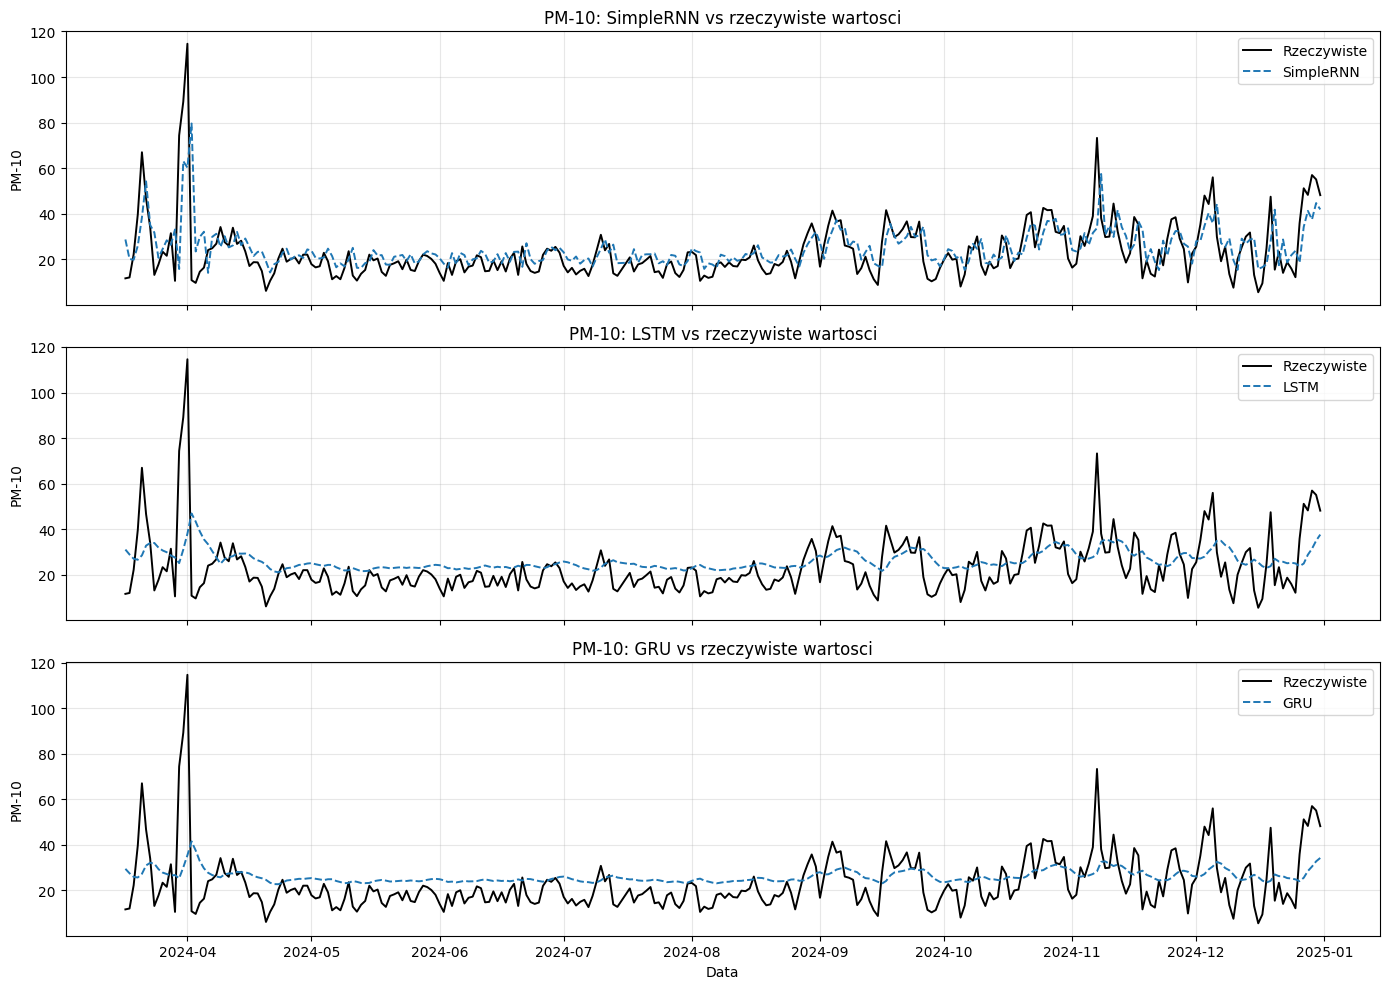

Najlepszy model to SimpleRNN, bo ma najnizszy test MSE i najlepiej odwzorowuje trend serii.


In [27]:
# Zadanie B: PM-10 prediction
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout

# Wczytaj dane z konkretnego pliku
csv_path = Path('PM10_kierunkowo.csv')
if not csv_path.exists():
    csv_path = Path('lab_5_6/PM10_kierunkowo.csv')

if not csv_path.exists():
    raise FileNotFoundError('Nie znaleziono pliku PM10_kierunkowo.csv.')

df = pd.read_csv(csv_path, sep=';')
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

print(f'Plik: {csv_path}')
print(f'Zakres dat: {df["data"].min().date()} -> {df["data"].max().date()}')
print(f'Liczba rekordow: {len(df)}')

# Przygotowanie szeregu czasowego
values = df['pm10'].astype('float32').to_numpy().reshape(-1, 1)
dates = df['data'].to_numpy()

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

# Sekwencje
look_back = 7
X, y, y_dates = [], [], []
for i in range(look_back, len(scaled)):
    X.append(scaled[i - look_back:i, 0])
    y.append(scaled[i, 0])
    y_dates.append(dates[i])

X = np.array(X).reshape(-1, look_back, 1)
y = np.array(y)
y_dates = np.array(y_dates)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# Podzial train/test (czasowy, bez tasowania)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
y_dates_test = y_dates[split_idx:]

val_split = int(0.85 * len(X_train))
X_fit, X_val = X_train[:val_split], X_train[val_split:]
y_fit, y_val = y_train[:val_split], y_train[val_split:]

def build_sequence_model(model_name):
    if model_name == 'SimpleRNN':
        recurrent_layer = SimpleRNN(32, activation='tanh')
    elif model_name == 'LSTM':
        recurrent_layer = LSTM(32)
    elif model_name == 'GRU':
        recurrent_layer = GRU(32)
    else:
        raise ValueError(f'Nieznany model: {model_name}')

    model = keras.Sequential([
        layers.Input(shape=(look_back, 1)),
        recurrent_layer,
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0),
        loss='mse',
        metrics=['mae']
    )
    return model

def inverse_scale(vector):
    return scaler.inverse_transform(np.asarray(vector).reshape(-1, 1)).flatten()

callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
model_order = ['SimpleRNN', 'LSTM', 'GRU']
histories_b = {}
predictions_b = {}
scores_b = []

for model_name in model_order:
    K.clear_session()
    tf.random.set_seed(42)

    model = build_sequence_model(model_name)
    history = model.fit(
        X_fit, y_fit,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=16,
        callbacks=callbacks,
        verbose=2
    )

    pred_scaled = model.predict(X_test, verbose=0).flatten()
    y_test_inv = inverse_scale(y_test)
    pred_inv = inverse_scale(pred_scaled)

    mse = float(np.mean((y_test_inv - pred_inv) ** 2))
    mae = float(np.mean(np.abs(y_test_inv - pred_inv)))

    histories_b[model_name] = history
    predictions_b[model_name] = pred_inv
    scores_b.append({'model': model_name, 'test_mse': mse, 'test_mae': mae})
    print(f'{model_name}: test MSE = {mse:.6f}, test MAE = {mae:.6f}')

scores_df_b = pd.DataFrame(scores_b).sort_values('test_mse').reset_index(drop=True)
best_model_b = scores_df_b.loc[0, 'model']
display(scores_df_b)
print(f'\nNajlepszy model: {best_model_b}')

# Porownanie predykcji
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, model_name in zip(axes, model_order):
    ax.plot(y_dates_test, y_test_inv, color='black', linewidth=1.4, label='Rzeczywiste')
    ax.plot(y_dates_test, predictions_b[model_name], linestyle='--', linewidth=1.4, label=model_name)
    ax.set_title(f'PM-10: {model_name} vs rzeczywiste wartosci')
    ax.set_ylabel('PM-10')
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Data')
plt.tight_layout()
plt.show()

print(f'Najlepszy model to {best_model_b}, bo ma najnizszy test MSE i najlepiej odwzorowuje trend serii.')

---

## Sprawdź, co umiesz — pytania kontrolne

**Część Lab 5:**
1. **Po co augmentacja danych?** (3 korzyści)
2. **Czym różni się on-the-fly od pre-processing augmentacji?**
3. **Jakie są 3 grupy technik augmentacji?**
4. **Co robi `ImageDataGenerator.flow()`?**
5. **Co znaczy overfitting i jak augmentacja temu zapobiega?**

**Część Lab 6:**
6. **Dlaczego CNN nie nadaje się do szeregów czasowych?**
7. **Co to jest stan ukryty $a_t$ w RNN?**
8. **Wymień 3 typy struktur RNN i ich zastosowania.**
9. **Co to vanishing gradient i jak LSTM go rozwiązuje?**
10. **Jakie są 3 bramki w LSTM i co każda robi?**

---

## Jedno zdanie do zapamiętania

> **Augmentacja to sztuczne tworzenie wariacji obrazów, żeby CNN nauczyła się generalizować. RNN/LSTM to sieci z pętlą rekurencyjną, które pamiętają kontekst — używamy ich do sekwencji (tekst, szeregi czasowe, audio). LSTM rozwiązuje vanishing gradient przez bramki kontrolujące przepływ pamięci.**

## Co dalej?

- **Transformery** — wyparły LSTM w NLP (Attention is All You Need)
- **CNN+RNN combo** — np. video classification
- **Transfer learning** — pretrenowane modele (ResNet, EfficientNet) zamiast trenowania od zera
- **Augmentacja audio/tekstu** — SpecAugment, back-translation